# Factor Construction and Composite Signal

## Purpose

Notebook 02 suggested that momentum is the only price-based signal worth carrying forward. This notebook turns that raw momentum rank into the traded signal used by the backtest.

The goals are:
1. Winsorize and z-score each factor cross-section so outliers do not dominate.
2. Neutralize the signal against sector membership by projecting out sector effects.
3. Compare momentum-only against a simple four-factor composite.
4. Save the sector-neutralized momentum signal for notebook 04.

### Terms used in this notebook

| Term | Meaning |
|------|---------|
| **Winsorization** | Clip extreme values at a threshold instead of dropping them |
| **Z-scoring** | Center to mean 0 and scale to standard deviation 1 |
| **Neutralization** | Regress a signal on unwanted exposures and keep the residual |
| **Composite signal** | A linear combination $c_t = \sum_k w_k f_{k,\perp}$ |
| **Sector matrix** | $D \in \{0,1\}^{N \times K}$, a one-hot sector-membership matrix |
| **Projection** | The linear algebra operation behind neutralization |
| **Information coefficient (IC)** ↻ | Spearman rank correlation used to compare candidate signals |
| **Return panel** $R$ ↻ | The monthly return matrix from notebook 01 |

## Outputs

- `momentum_signal.csv`: sector-neutralized momentum, the signal used in the backtest
- `composite_4factor.csv`: a simple four-factor composite kept for comparison
- `factor_*_neutralized.csv`: neutralized versions of the individual factors

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Winsorization and Z-Scoring](#winsorization-and-z-scoring)
3. [Sector Neutralization](#sector-neutralization)
4. [Composite Assembly and Comparison](#composite-assembly-and-comparison)
5. [IC Comparison: Momentum vs. Composite](#ic-comparison-momentum-vs-composite)
6. [Conclusion](#conclusion)


## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/03_factor_construction', exist_ok=True)

RANDOM_STATE = 3

In [2]:
"""
==================================
Load factor exposures, returns, sectors
==================================
"""
factor_names = ['momentum', 'value', 'quality', 'lowvol']
factor_dict = {n: pd.read_csv(f'../data/processed/factor_{n}.csv', index_col=0, parse_dates=True) for n in factor_names}
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_sector = pd.read_csv('../data/processed/sector_mapping.csv')

# Build sector lookup
sector_map = dict(zip(df_sector['ticker'], df_sector['sector']))

print(f"Loaded {len(factor_names)} factors")
print(f"Returns: {df_returns.shape}")

Loaded 4 factors
Returns: (251, 501)


## Winsorization and Z-Scoring

Raw factor values can contain large outliers. Winsorization clips those extremes rather than dropping the stock entirely. Here we cap each monthly cross-section at $\pm 3$ standard deviations around its mean.

After clipping, we z-score within each date:

$$\tilde f_{t,i}=\frac{f_{t,i}-\bar f_t}{\mathrm{std}(f_t)}.$$

This gives each factor row mean 0 and standard deviation 1, so later comparisons are not driven by arbitrary units.

In [3]:
"""
==================================
Winsorize and z-score
==================================
"""
def winsorize(series, sigma=3):
    """Clip at ±sigma standard deviations around the mean."""
    mu = series.mean()
    s = series.std()
    if s == 0 or pd.isna(s):
        return series
    return series.clip(lower=mu - sigma*s, upper=mu + sigma * s)

def zscore(series):
    """Cross-sectional z-score."""
    mu = series.mean()
    s = series.std()
    if s == 0 or pd.isna(s):
        return series * 0
    return (series - mu)/s

factor_z = {}
for name, df_f in factor_dict.items():
    df_w = df_f.apply(winsorize, axis=1)
    df_z = df_w.apply(zscore, axis=1)
    factor_z[name] = df_z
    print(f"{name}: z-scores, shape={df_z.shape}")

momentum: z-scores, shape=(251, 501)
value: z-scores, shape=(251, 501)


quality: z-scores, shape=(251, 501)
lowvol: z-scores, shape=(251, 501)


## Sector Neutralization

A raw momentum score may contain sector bets. For example, if Technology had a strong year, a momentum portfolio might become mostly a Technology portfolio. That may be a valid trade, but it is not a clean test of stock selection within sectors.

To neutralize sectors, create a sector dummy matrix

$$D \in \{0,1\}^{N \times K}.$$

For one factor vector $f \in \mathbb{R}^N$, the projection onto the sector span is

$$P_D f = D(D^\top D)^{-1}D^\top f.$$

The sector-neutralized signal is the residual:

$$f_\perp = (I-P_D)f.$$

This is the same as running a cross-sectional OLS regression of the factor on sector dummies and keeping the residuals. The residual has zero linear exposure to the sector dummy columns used in the regression.

The code also mentions size, but with this dataset we only have a weak price-based size proxy. I would not interpret it as a true market-cap neutralization without real shares-outstanding data.

In [4]:
"""
==================================
Sector neutralization via cross-sectional regression on dummies
==================================
"""
def neutralize_against_sector(factor_row, sector_map):
    """Regress factor on sector dummies, return residuals."""
    tickers = factor_row.index
    sectors = pd.Series([sector_map.get(t, 'Unknown') for t in tickers], index=tickers)

    # One-hot encode
    indicators = pd.get_dummies(sectors, drop_first=True).astype(float)
    indicators['intercept'] = 1.0

    # Mask valid
    mask = factor_row.notna()
    if mask.sum() < 30:
        return factor_row

    y = factor_row[mask].values
    X = indicators.loc[mask].values

    # OLS via least squares
    beta, _, _, _ = np.linalg.lstsq(X,y)
    resid = y - X @ beta

    out = pd.Series(np.nan, index=factor_row.index)
    out[mask] = resid
    return out

factor_neut = {}
for name, df_z in factor_z.items():
    print(f"Neutralizing {name}...")
    df_neut = df_z.apply(lambda row: neutralize_against_sector(row, sector_map), axis=1)
    # Re-z-score the residuals so they're back on a common scale
    df_neut = df_neut.apply(zscore, axis=1)
    factor_neut[name] = df_neut

print("Sector neutralization complete.")

Neutralizing momentum...


Neutralizing value...


Neutralizing quality...


Neutralizing lowvol...


Sector neutralization complete.


As in notebook 02, we use a sample-size guardrail. If fewer than 30 stocks have valid data in a month, we skip neutralization for that row rather than fit a noisy cross-sectional regression. This mostly affects early or sparse parts of the panel.

## Composite Assembly and Comparison

We compare two candidate signals:

1. **Momentum-only:** the sector-neutralized momentum residual $f_{m,\perp}$, re-z-scored. This is the signal passed to the backtest.
2. **Four-factor composite:** an equal-weight average of the neutralized factor vectors,

$$c_t = \frac{1}{4}\sum_{k=1}^4 f_{k,\perp}(t).$$

This is a useful sanity check. If the composite improves IC, the extra factors are helping. If it gets worse, the added factors are diluting momentum rather than diversifying it.

In [5]:
"""
==================================
Build momentum-only signal and 4-factor composite
==================================
"""
# Momentum only
df_momentum_signal = factor_neut['momentum'].apply(zscore, axis=1)
print(f"Momentum-only signal: {df_momentum_signal.shape}")

# 4-factor equal-weight composite
common_dates = factor_neut['momentum'].index
common_tickers = factor_neut['momentum'].columns

for name in factor_names:
    common_dates = common_dates.intersection(factor_neut[name].index)
    common_tickers = common_tickers.intersection(factor_neut[name].columns)

df_composite_4f = pd.DataFrame(0.0, index=common_dates, columns=common_tickers)
count_df = pd.DataFrame(0, index=common_dates, columns=common_tickers)

for name in factor_names:
    df_f = factor_neut[name].loc[common_dates, common_tickers]
    df_composite_4f = df_composite_4f.add(df_f.fillna(0))
    count_df = count_df.add(df_f.notna().astype(int))

df_composite_4f = df_composite_4f / count_df.replace(0, np.nan)
df_composite_4f[count_df < 3] = np.nan
df_composite_4f = df_composite_4f.apply(zscore, axis=1)

print(f"4-factor composite: {df_composite_4f.shape}")
print(f"\nOur main signal will be momentum-only. The 4-factor composite is kept for comparison.")

Momentum-only signal: (251, 501)


4-factor composite: (251, 501)

Our main signal will be momentum-only. The 4-factor composite is kept for comparison.


## Composite vs. Single Factors

IC Comparison: Neutralized Factors, Momentum-Only, and 4-Factor Composite



,mean,std,ic_ir
momentum,0.0068,0.1576,0.1505
value,-0.0198,0.1344,-0.5111
quality,0.0013,0.1597,0.0282
lowvol,-0.0169,0.1772,-0.3298
momentum_only,0.0068,0.1576,0.1505
4factor_composite,-0.0078,0.1688,-0.1593


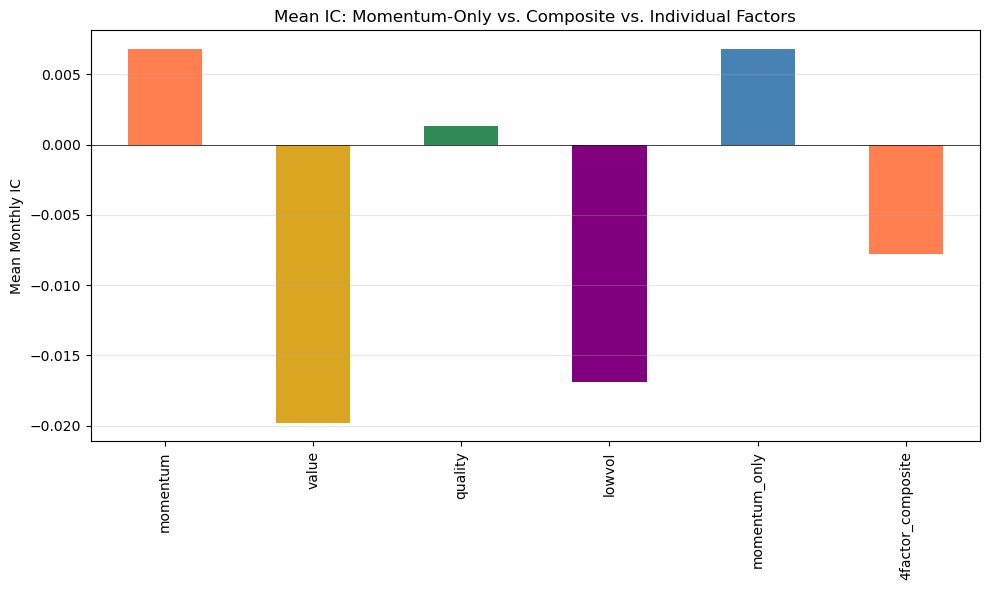

In [6]:
"""
==================================
Compare IC: momentum-only vs. 4-factor composite vs. individual factors
==================================
"""
def compute_monthly_ic(factor_df, return_df):
    common_dates = factor_df.index.intersection(return_df.index)
    common_tickers = factor_df.columns.intersection(return_df.columns)
    ic_series = []
    for date in common_dates:
        f = factor_df.loc[date, common_tickers]
        r = return_df.loc[date, common_tickers]
        mask = f.notna() & r.notna()
        if mask.sum() < 20:
            ic_series.append(np.nan)
            continue
        ic, _ = spearmanr(f[mask], r[mask])
        ic_series.append(ic)
    return pd.Series(ic_series, index=common_dates)

# Compute IC for all signals
ic_compare = {}
for name in factor_names:
    ic_compare[name] = compute_monthly_ic(factor_neut[name], df_returns)
ic_compare['momentum_only'] = compute_monthly_ic(df_momentum_signal, df_returns)
ic_compare['4factor_composite'] = compute_monthly_ic(df_composite_4f, df_returns)

df_ic_compare = pd.DataFrame(ic_compare)

summary = df_ic_compare.describe().T[['mean', 'std']]
summary['ic_ir'] = summary['mean'] / summary['std'] * np.sqrt(12)
summary = summary.round(4)

print("IC Comparison: Neutralized Factors, Momentum-Only, and 4-Factor Composite\n")
display(summary)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral', 'goldenrod', 'seagreen', 'purple', 'steelblue', 'coral']
summary['mean'].plot(kind='bar', ax=ax, color=['coral', 'goldenrod', 'seagreen', 'purple', 'steelblue', 'coral'])
ax.set_ylabel('Mean Monthly IC')
ax.set_title('Mean IC: Momentum-Only vs. Composite vs. Individual Factors')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/03_factor_construction/composite_vs_single_ic.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
"""
==================================
Save signals and neutralized factors
==================================
"""
# The headline signal: momentum-only, sector-neutralized
df_momentum_signal.to_csv('../data/processed/momentum_signal.csv')

# The 4-factor composite: kept for comparison
df_composite_4f.to_csv('../data/processed/composite_4factor.csv')

# Individual neutralized factors
for name in factor_names:
    factor_neut[name].to_csv(f'../data/processed/factor_{name}_neutralized.csv')

print("Saved:")
print("  - momentum_signal.csv          (momentum-only, sector-neutralized)")
print("  - composite_4factor.csv         (4-factor equal-weight — comparison only)")
for name in factor_names:
    print(f"  - factor_{name}_neutralized.csv")

Saved:
  - momentum_signal.csv          (momentum-only, sector-neutralized)
  - composite_4factor.csv         (4-factor equal-weight — comparison only)
  - factor_momentum_neutralized.csv
  - factor_value_neutralized.csv
  - factor_quality_neutralized.csv
  - factor_lowvol_neutralized.csv


## Conclusion

The comparison supports a simple choice: use **momentum-only, sector-neutralized** as the headline signal.

- Sector neutralization slightly improves the momentum IC.
- The equal-weight four-factor composite is worse, because it mixes momentum with weak or negative proxy signals.
- The result is also easier to explain: rank stocks by momentum within a sector-neutral framework, then trade the top decile.

Notebook 04 turns this signal into portfolio weights and asks whether it produces returns net of transaction costs.